In [23]:
import requests
import csv
import pandas as pd
import math
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import time
import random
from datetime import datetime, date
import statistics
import requests
from scipy.stats import skew, kurtosis
from scipy import stats
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import johnsonsu
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm

In [14]:
def get_data(ticker, size='full', date_filter=None):
    """ Retrieve time series data for the price of a security in data frame format
        Sorts so that first date is first index, filters on date if given, renames columns and converts datatypes

    Args:
        ticker (string): The ticker for the security to pull data from
        size (string): 'full' since 1999, 'compact' is last 100 trading days
        date_filter (date string): Filters  data to  keep data only the filter date onward

    Returns:
        df: A dataframe with open, close, high, low, adj close price, volume, split coef, date
    """
    key='&apikey=ZKMMTO1ATDBLXH2K' # API Key
    api_ticker=f'&symbol={ticker}' # Ticker
    endpoint='function=TIME_SERIES_DAILY_ADJUSTED' # Called 'function', the dataset we want
    size=f'&outputsize={size}'
    web='https://www.alphavantage.co/query?'
    url =web+endpoint+api_ticker+size+key

    r = requests.get(url)
    # print(r.status_code) # 200 good, 400 bad
    data = r.json()

    # print(data.keys()) #printing the keys
    meta = data['Meta Data']
    time_series_data = data['Time Series (Daily)']

    ts_df = pd.DataFrame.from_dict(time_series_data, orient='index').reset_index().rename(columns={'index': 'Date'})
    clean_cols_dict = {'1. open': 'Open', '2. high': 'High', '3. low': 'Low', '4. close': 'Close', # Dictionary to convert the names of the columns
                '5. adjusted close': 'Adj Close', '6. volume': 'Volume', '7. dividend amount': 'Dividend', '8. split coefficient': 'Split Coef'}
    ts_df = ts_df.rename(columns=clean_cols_dict)

    ts_df['Date'] = pd.to_datetime(ts_df['Date'])
    if date_filter is not None:
        date_filter = pd.to_datetime(date_filter)
        ts_df = ts_df[ts_df['Date'] >= date_filter]


    ts_df = ts_df.sort_values(by='Date', ascending=True).reset_index().drop(columns='index')
    ts_df['Adj Close'] = ts_df['Adj Close'].astype('float').round(4)
    ts_df['Ticker'] = ticker
    
    return ts_df

In [15]:
def calculate_returns(df, frequency=1):
    """ Calculate the log returns of a security given a df with its prices over a time period

    Args:
        df (dataframe): A dataframe with columns Date, Ticker, Volume, and Adj Close
        frequency (int, optional): How often you want to calculate a return Defaults to 1.

    Returns:
        df: The dataframe from the start with an additional 'Log Return' column which is the log return over the interval for each row
    """
    returns_df = df[['Date', 'Ticker', 'Volume', 'Adj Close']].copy()
    returns_df['Adj Close'] = returns_df['Adj Close'].astype('float')
    returns_df['Log Return'] = np.log(
        returns_df['Adj Close'] / returns_df['Adj Close'].shift(frequency)
    )
    returns_df = returns_df.dropna()

    # If frequency > 1, keep only every `frequency`-th row
    if frequency > 1:
        returns_df = returns_df.iloc[frequency-1::frequency].reset_index(drop=True)

    return returns_df



In [ ]:
# Get date, volume, price, log return for a ticker — 80/20 train/test split

bmw_df = get_data('BMW.FRK', size='full', date_filter='2000-01-01')
bmw_df = bmw_df[bmw_df['Date'] <= pd.to_datetime('2026-01-01')]
returns_df = calculate_returns(bmw_df, frequency=1).rename(columns={'Adj Close': 'Price'})

n = len(returns_df)
train_r = returns_df['Log Return'].iloc[:int(n * 0.8)]
test_r = returns_df['Log Return'].iloc[int(n * 0.8):]


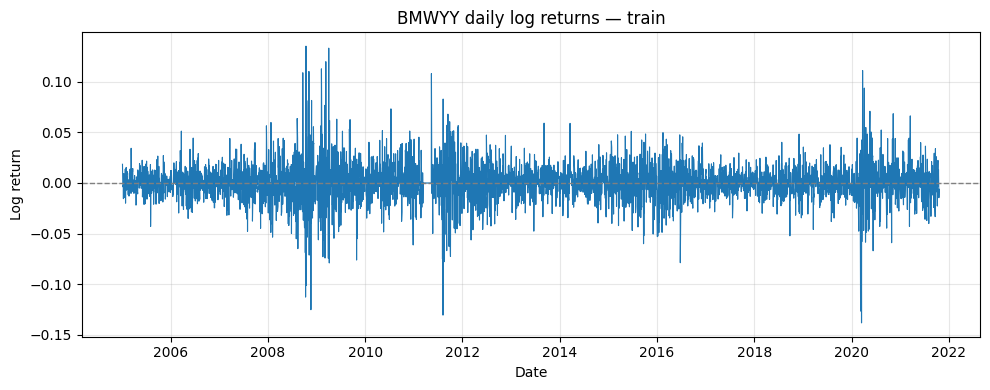

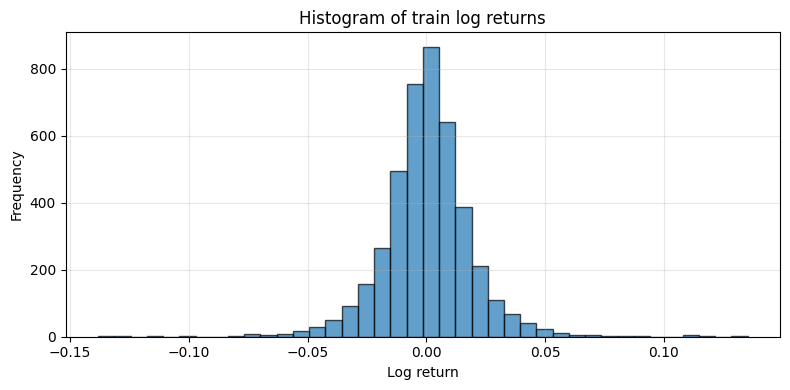

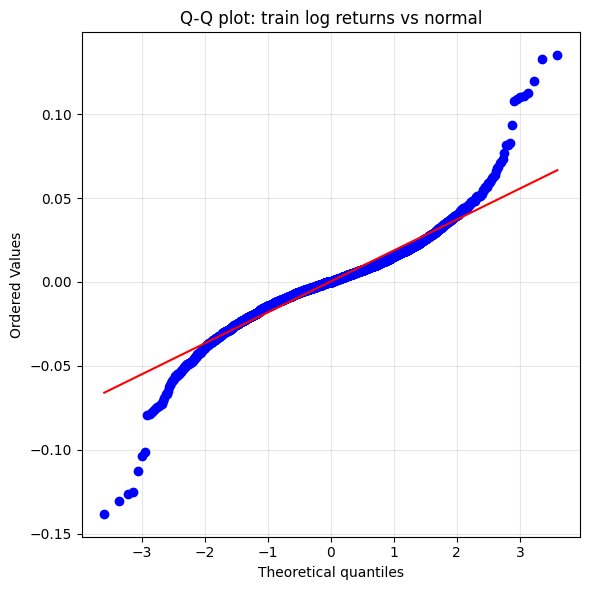

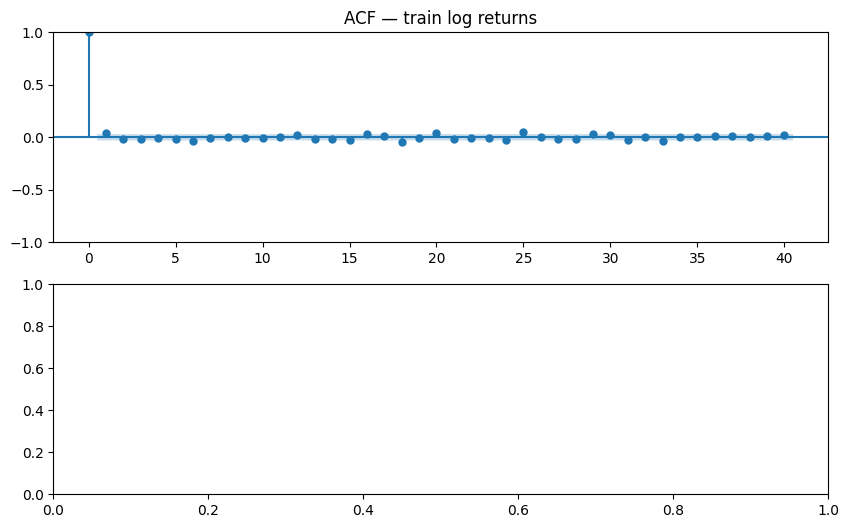

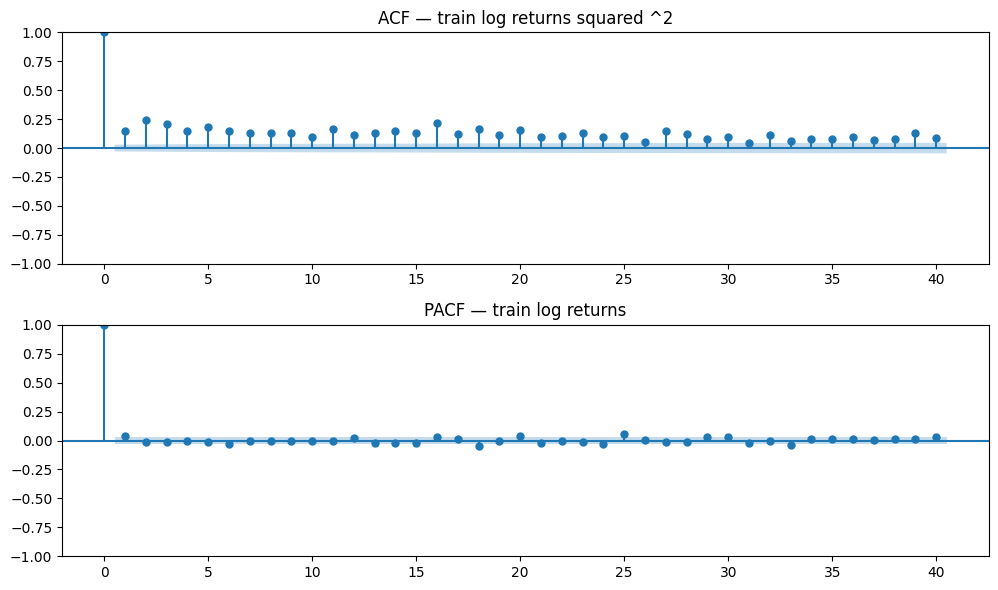

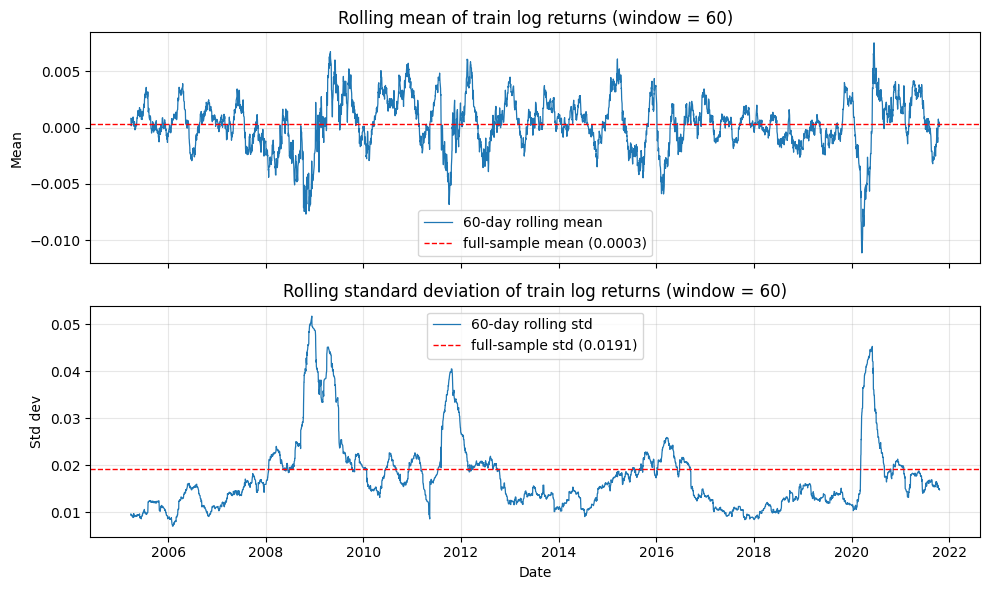

In [17]:
# Print graphs for: Log_r over time, Histogram, Q-Q plot, ACF, PACF

train_end = int(n * 0.8)
train_dates = returns_df['Date'].iloc[:train_end]
y_train = train_r.dropna()

# 1. Log returns over time
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_dates, y_train.values, linewidth=0.8)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('BMWYY daily log returns — train')
ax.set_xlabel('Date')
ax.set_ylabel('Log return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train, bins=40, edgecolor='black', alpha=0.7)
ax.set_title('Histogram of train log returns')
ax.set_xlabel('Log return')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Q-Q plot vs normal
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(y_train, dist='norm', plot=ax)
ax.set_title('Q-Q plot: train log returns vs normal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(y_train, lags=40, ax=axes[0])
axes[0].set_title('ACF — train log returns')

fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(y_train ** 2, lags=40, ax=axes[0])
axes[0].set_title('ACF — train log returns squared ^2')

plot_pacf(y_train, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — train log returns')

plt.tight_layout()
plt.show()

# 5. Rolling mean and rolling std (with full-sample reference lines)
w = 60
roll_mean = y_train.rolling(w).mean()
roll_std = y_train.rolling(w).std()
avg_mean = y_train.mean()
avg_std = y_train.std()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(train_dates, roll_mean, linewidth=0.9, label=f'{w}-day rolling mean')
axes[0].axhline(avg_mean, color='red', linestyle='--', linewidth=1,
                 label=f'full-sample mean ({avg_mean:.4f})')
axes[0].set_title(f'Rolling mean of train log returns (window = {w})')
axes[0].set_ylabel('Mean')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_dates, roll_std, linewidth=0.9, label=f'{w}-day rolling std')
axes[1].axhline(avg_std, color='red', linestyle='--', linewidth=1,
                 label=f'full-sample std ({avg_std:.4f})')
axes[1].set_title(f'Rolling standard deviation of train log returns (window = {w})')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Std dev')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
# Fit ARMA + GARCH model grid on train data
# Note: statsmodels fits the ARMA mean; arch fits GARCH to the ARMA residuals.
# alpha_lag is the ARCH/GARCH alpha order p, beta_lag is the GARCH beta order q.

from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import warnings

scale = 100  # use percent returns for better numerical stability in GARCH
train_y = train_r.dropna() * scale
test_y = test_r.dropna() * scale

fitted_models = {}
model_grid_rows = []

for ar_lag, ma_lag, alpha_lag, beta_lag in product(range(3), range(3), range(3), range(3)):
    order_label = f'ARMA({ar_lag},{ma_lag}) + GARCH({alpha_lag},{beta_lag})'
    key = (ar_lag, ma_lag, alpha_lag, beta_lag)

    # GARCH(0, q) is not identified because beta terms need past conditional variance
    # generated by an innovation term. Keep it in the grid table as skipped.
    if alpha_lag == 0 and beta_lag > 0:
        model_grid_rows.append({
            'key': key,
            'order': order_label,
            'ar': ar_lag,
            'ma': ma_lag,
            'alpha_lag': alpha_lag,
            'beta_lag': beta_lag,
            'status': 'skipped',
            'error': 'GARCH(0, q) is not identified'
        })
        continue

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            arma_fit = ARIMA(train_y, order=(ar_lag, 0, ma_lag), trend='c').fit()

            arma_resid = pd.Series(arma_fit.resid, index=train_y.index).dropna()

            if alpha_lag == 0 and beta_lag == 0:
                garch_fit = None
            else:
                garch_fit = arch_model(
                    arma_resid,
                    mean='Zero',
                    vol='GARCH',
                    p=alpha_lag,
                    o=1,
                    q=beta_lag,
                    dist='t',
                    rescale=False
                ).fit(disp='off')

        mean_param_count = max(len(arma_fit.params) - 1, 1)  # exclude ARIMA sigma2 when GARCH handles variance
        vol_param_count = 1 if garch_fit is None else len(garch_fit.params)
        n_params = mean_param_count + vol_param_count

        if garch_fit is None:
            sigma = arma_resid.std(ddof=1)
            std_resid = arma_resid / sigma

            def neg_t_ll(nu):
                nu = max(nu, 2.01)
                return -np.sum(stats.t.logpdf(std_resid, df=nu))

            nu = minimize_scalar(neg_t_ll, bounds=(2.01, 50), method='bounded').x
            train_loglik = np.sum(stats.t.logpdf(arma_resid, df=nu, loc=0, scale=sigma))
            n_params += 1  # degrees of freedom for homoskedastic Student-t
        else:
            nu = float(garch_fit.params['nu'])
            train_loglik = float(garch_fit.loglikelihood)

        train_aic = 2 * n_params - 2 * train_loglik
        train_bic = np.log(len(arma_resid)) * n_params - 2 * train_loglik

        fitted_models[key] = {
            'order': order_label,
            'ar': ar_lag,
            'ma': ma_lag,
            'alpha_lag': alpha_lag,
            'beta_lag': beta_lag,
            'arma_fit': arma_fit,
            'garch_fit': garch_fit,
            'n_params': n_params,
            'nu': nu,
            'scale': scale,
            'train_loglik': train_loglik,
            'train_AIC': train_aic,
            'train_BIC': train_bic,
        }

        model_grid_rows.append({
            'key': key,
            'order': order_label,
            'ar': ar_lag,
            'ma': ma_lag,
            'alpha_lag': alpha_lag,
            'beta_lag': beta_lag,
            'status': 'fit',
            'n_params': n_params,
            'nu': nu,
            'train_loglik': train_loglik,
            'train_AIC': train_aic,
            'train_BIC': train_bic,
            'train_arma_AIC': arma_fit.aic,
            'train_arma_BIC': arma_fit.bic,
            'train_garch_AIC': np.nan if garch_fit is None else garch_fit.aic,
            'train_garch_BIC': np.nan if garch_fit is None else garch_fit.bic,
            'error': ''
        })

    except Exception as e:
        model_grid_rows.append({
            'key': key,
            'order': order_label,
            'ar': ar_lag,
            'ma': ma_lag,
            'alpha_lag': alpha_lag,
            'beta_lag': beta_lag,
            'status': 'failed',
            'error': str(e)
        })

model_grid_df = pd.DataFrame(model_grid_rows)
model_grid_df = model_grid_df.sort_values(by='train_AIC', ascending=True)

print(f"Fit {len(fitted_models)} models out of {len(model_grid_df)} grid combinations.")
display(model_grid_df[[
    'order', 'status', 'n_params', 'nu', 'train_loglik', 'train_AIC', 'train_BIC', 'error'
]].round(4))

Fit 63 models out of 81 grid combinations.


,order,status,n_params,nu,train_loglik,train_AIC,train_BIC,error
13,"ARMA(0,1) + GARCH(1,1)",fit,7.0,5.9282,-8078.9046,16171.8093,16216.3298,
31,"ARMA(1,0) + GARCH(1,1)",fit,7.0,5.9283,-8079.0008,16172.0017,16216.5222,
14,"ARMA(0,1) + GARCH(1,2)",fit,8.0,5.9204,-8078.6576,16173.3152,16224.1958,
32,"ARMA(1,0) + GARCH(1,2)",fit,8.0,5.9205,-8078.7500,16173.5001,16224.3807,
40,"ARMA(1,1) + GARCH(1,1)",fit,8.0,5.9272,-8078.8371,16173.6742,16224.5547,
...,...,...,...,...,...,...,...,...
56,"ARMA(2,0) + GARCH(0,2)",skipped,NaN,NaN,NaN,NaN,NaN,"GARCH(0, q) is not identified"
64,"ARMA(2,1) + GARCH(0,1)",skipped,NaN,NaN,NaN,NaN,NaN,"GARCH(0, q) is not identified"
65,"ARMA(2,1) + GARCH(0,2)",skipped,NaN,NaN,NaN,NaN,NaN,"GARCH(0, q) is not identified"
73,"ARMA(2,2) + GARCH(0,1)",skipped,NaN,NaN,NaN,NaN,NaN,"GARCH(0, q) is not identified"


In [32]:
# Select best models on train data using in-sample Student-t AIC/BIC

train_scores_df = (
    pd.DataFrame([
        {
            'key': key,
            'order': model['order'],
            'n_params': model['n_params'],
            'nu': model['nu'],
            'train_loglik': model['train_loglik'],
            'train_AIC': model['train_AIC'],
            'train_BIC': model['train_BIC'],
        }
        for key, model in fitted_models.items()
    ])
    .sort_values('train_AIC')
    .reset_index(drop=True)
)

best_aic_key = train_scores_df.loc[train_scores_df['train_AIC'].idxmin(), 'key']
best_bic_key = train_scores_df.loc[train_scores_df['train_BIC'].idxmin(), 'key']
selected_model_keys = {
    'best_AIC': best_aic_key,
    'best_BIC': best_bic_key,
}

best_aic_row = train_scores_df.loc[train_scores_df['key'] == best_aic_key].iloc[0]
best_bic_row = train_scores_df.loc[train_scores_df['key'] == best_bic_key].iloc[0]

print('Best in-sample AIC model (Student-t):')
print(f"  {best_aic_row['order']}  AIC={best_aic_row['train_AIC']:.2f}, BIC={best_aic_row['train_BIC']:.2f}, nu={best_aic_row['nu']:.2f}")

print('\nBest in-sample BIC model (Student-t):')
print(f"  {best_bic_row['order']}  AIC={best_bic_row['train_AIC']:.2f}, BIC={best_bic_row['train_BIC']:.2f}, nu={best_bic_row['nu']:.2f}")

print('\nAll train models sorted by in-sample AIC:')
display(train_scores_df.round(4))


def _one_step_mean_forecast(arma_res):
    fc = arma_res.get_forecast(steps=1).predicted_mean
    return float(np.asarray(fc).ravel()[0])


def _next_garch_variance(omega, alpha, beta, eps_hist, sig2_hist):
    """One-step GARCH variance forecast from fixed parameters and lag history."""
    var = omega
    for i, coeff in enumerate(alpha):
        var += coeff * eps_hist[-(i + 1)] ** 2
    for j, coeff in enumerate(beta):
        var += coeff * sig2_hist[-(j + 1)]
    return max(var, 1e-12)


def forecast_model_components(model, y):
    """One-step-ahead rolling forecasts with fixed train params and updated state."""
    y = np.asarray(y, dtype=float)
    n_steps = len(y)
    arma_res = model['arma_fit']
    garch_fit = model['garch_fit']

    mean_forecast = np.empty(n_steps)
    variance_forecast = np.empty(n_steps)

    if garch_fit is None:
        train_resid = pd.Series(arma_res.resid).dropna()
        constant_var = float(train_resid.var(ddof=1))
        for i in range(n_steps):
            mean_forecast[i] = arma_res.get_forecast(steps=1).predicted_mean.iloc[0]
            variance_forecast[i] = constant_var
            arma_res = arma_res.append([y[i]], refit=False)
    else:
        params = garch_fit.params
        omega = float(params['omega'])
        p = model['alpha_lag']
        q = model['beta_lag']
        alpha = np.array([float(params[f'alpha[{k}]']) for k in range(1, p + 1)])
        beta = np.array([float(params[f'beta[{k}]']) for k in range(1, q + 1)])

        train_eps = np.asarray(pd.Series(arma_res.resid).dropna())
        train_sig2 = np.asarray(garch_fit.conditional_volatility ** 2)

        eps_hist = list(train_eps[-max(p, 1):])
        sig2_hist = list(train_sig2[-max(q, 1):])
        sigma2 = _next_garch_variance(omega, alpha, beta, eps_hist, sig2_hist)

        for i in range(n_steps):
            mean_forecast[i] = _one_step_mean_forecast(arma_res)
            variance_forecast[i] = sigma2

            resid = y[i] - mean_forecast[i]
            eps_hist.append(resid)
            sig2_hist.append(sigma2)
            sigma2 = _next_garch_variance(omega, alpha, beta, eps_hist, sig2_hist)

            arma_res = arma_res.append([y[i]], refit=False)

    residuals = y - mean_forecast
    standardized_residuals = residuals / np.sqrt(variance_forecast)

    return mean_forecast, variance_forecast, residuals, standardized_residuals


def score_model_on_series(model, y):
    """Score held-out data under Student-t errors with trained mean and variance forecasts."""
    mean_forecast, variance_forecast, residuals, standardized_residuals = forecast_model_components(model, y)

    nu = model['nu']
    scale = np.sqrt(variance_forecast)
    loglik = stats.t.logpdf(residuals, df=nu, loc=0, scale=scale).sum()
    n_obs = len(y)
    k = model['n_params']

    return {
        'loglik': loglik,
        'AIC': 2 * k - 2 * loglik,
        'BIC': np.log(n_obs) * k - 2 * loglik,
        'RMSE': np.sqrt(np.mean(residuals ** 2)),
        'MAE': np.mean(np.abs(residuals)),
        'mean_forecast': mean_forecast,
        'variance_forecast': variance_forecast,
        'residuals': residuals,
        'standardized_residuals': standardized_residuals,
    }

Best in-sample AIC model (Student-t):
  ARMA(0,1) + GARCH(1,1)  AIC=16171.81, BIC=16216.33, nu=5.93

Best in-sample BIC model (Student-t):
  ARMA(0,1) + GARCH(1,1)  AIC=16171.81, BIC=16216.33, nu=5.93

All train models sorted by in-sample AIC:


,key,order,n_params,nu,train_loglik,train_AIC,train_BIC
0,"(0, 1, 1, 1)","ARMA(0,1) + GARCH(1,1)",7,5.9282,-8078.9046,16171.8093,16216.3298
1,"(1, 0, 1, 1)","ARMA(1,0) + GARCH(1,1)",7,5.9283,-8079.0008,16172.0017,16216.5222
2,"(0, 1, 1, 2)","ARMA(0,1) + GARCH(1,2)",8,5.9204,-8078.6576,16173.3152,16224.1958
3,"(1, 0, 1, 2)","ARMA(1,0) + GARCH(1,2)",8,5.9205,-8078.7500,16173.5001,16224.3807
4,"(1, 1, 1, 1)","ARMA(1,1) + GARCH(1,1)",8,5.9272,-8078.8371,16173.6742,16224.5547
...,...,...,...,...,...,...,...
58,"(2, 0, 0, 0)","ARMA(2,0) + GARCH(0,0)",5,9.4504,-8641.9509,17293.9017,17325.7021
59,"(0, 2, 0, 0)","ARMA(0,2) + GARCH(0,0)",5,9.4499,-8642.0078,17294.0156,17325.8160
60,"(1, 1, 0, 0)","ARMA(1,1) + GARCH(0,0)",5,9.4490,-8642.2344,17294.4687,17326.2691
61,"(2, 2, 0, 0)","ARMA(2,2) + GARCH(0,0)",7,9.4528,-8641.9906,17297.9813,17342.5018


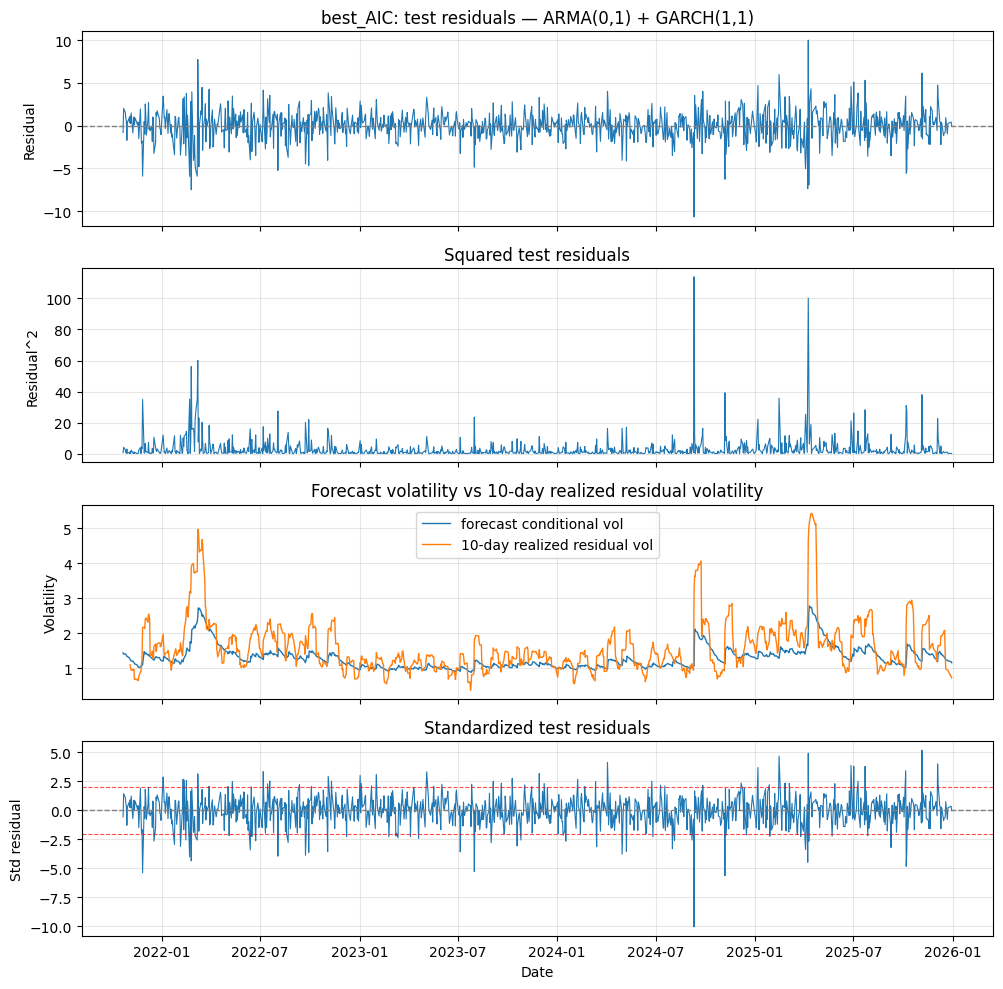

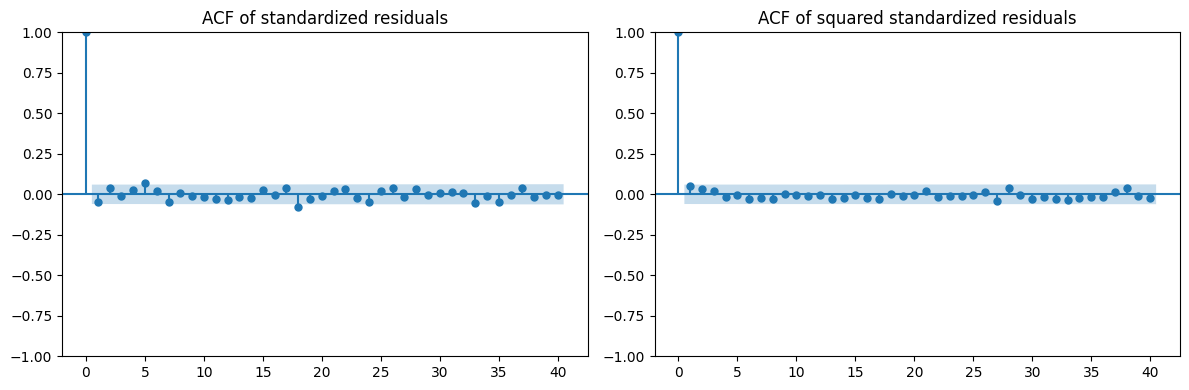

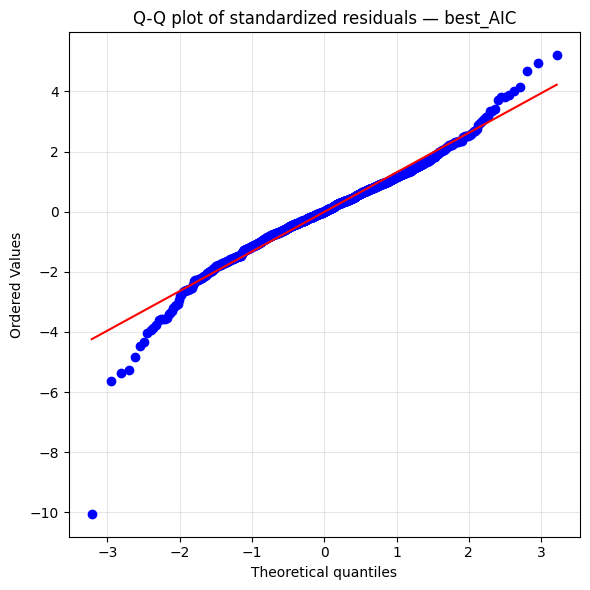

In-sample AIC and BIC selected the same model: ARMA(0,1) + GARCH(1,1)
Test summary for selected models:


,selection,order,nu,test_loglik,test_AIC,test_BIC,test_RMSE,test_MAE,std_resid_mean,std_resid_std,Ljung_Box_resid_p_lag10,Ljung_Box_sq_resid_p_lag10,ARCH_LM_p_lag10
0,best_AIC,"ARMA(0,1) + GARCH(1,1)",5.9282,-2023.8608,4061.7216,4096.543,1.7458,1.2667,-0.0079,1.3386,0.1868,0.7693,0.8277


In [33]:
# Test the in-sample-selected models and inspect residual diagnostics

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf

unique_selected = []
for label, key in selected_model_keys.items():
    if key not in [item['key'] for item in unique_selected]:
        unique_selected.append({'selection': label, 'key': key})
    else:
        # If AIC and BIC picked the same model, keep the note in the summary table later.
        pass

test_dates = returns_df.loc[test_y.index, 'Date']
test_summary_rows = []

for selected in unique_selected:
    selection = selected['selection']
    key = selected['key']
    model = fitted_models[key]
    score = score_model_on_series(model, test_y)

    residuals = pd.Series(score['residuals'], index=test_dates, name='residual')
    squared_residuals = residuals ** 2
    conditional_vol = pd.Series(np.sqrt(score['variance_forecast']), index=test_dates, name='forecast_vol')
    realized_vol_10 = residuals.rolling(10).std()
    standardized_residuals = pd.Series(score['standardized_residuals'], index=test_dates, name='standardized_residual')

    lb_resid = acorr_ljungbox(standardized_residuals.dropna(), lags=[10], return_df=True)
    lb_sq_resid = acorr_ljungbox((standardized_residuals.dropna() ** 2), lags=[10], return_df=True)
    arch_lm_stat, arch_lm_pvalue, _, _ = het_arch(standardized_residuals.dropna(), nlags=10)

    test_summary_rows.append({
        'selection': selection,
        'order': model['order'],
        'nu': model['nu'],
        'test_loglik': score['loglik'],
        'test_AIC': score['AIC'],
        'test_BIC': score['BIC'],
        'test_RMSE': score['RMSE'],
        'test_MAE': score['MAE'],
        'std_resid_mean': standardized_residuals.mean(),
        'std_resid_std': standardized_residuals.std(),
        'Ljung_Box_resid_p_lag10': lb_resid['lb_pvalue'].iloc[0],
        'Ljung_Box_sq_resid_p_lag10': lb_sq_resid['lb_pvalue'].iloc[0],
        'ARCH_LM_p_lag10': arch_lm_pvalue
    })

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(residuals.index, residuals.values, linewidth=0.8)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title(f'{selection}: test residuals — {model["order"]}')
    axes[0].set_ylabel('Residual')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(squared_residuals.index, squared_residuals.values, linewidth=0.8)
    axes[1].set_title('Squared test residuals')
    axes[1].set_ylabel('Residual^2')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(conditional_vol.index, conditional_vol.values, linewidth=1,
                 label='forecast conditional vol')
    axes[2].plot(realized_vol_10.index, realized_vol_10.values, linewidth=1,
                 label='10-day realized residual vol')
    axes[2].set_title('Forecast volatility vs 10-day realized residual volatility')
    axes[2].set_ylabel('Volatility')
    axes[2].legend(loc='best')
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(standardized_residuals.index, standardized_residuals.values, linewidth=0.8)
    axes[3].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[3].axhline(2, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[3].axhline(-2, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    axes[3].set_title('Standardized test residuals')
    axes[3].set_xlabel('Date')
    axes[3].set_ylabel('Std residual')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(standardized_residuals.dropna(), lags=min(40, len(standardized_residuals.dropna()) // 2), ax=axes[0])
    axes[0].set_title('ACF of standardized residuals')

    plot_acf((standardized_residuals.dropna() ** 2), lags=min(40, len(standardized_residuals.dropna()) // 2), ax=axes[1])
    axes[1].set_title('ACF of squared standardized residuals')

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 6))
    stats.probplot(standardized_residuals.dropna(), dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot of standardized residuals — {selection}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Add a duplicate-selection note if both criteria picked the same model.
if selected_model_keys['best_AIC'] == selected_model_keys['best_BIC']:
    model = fitted_models[selected_model_keys['best_AIC']]
    print(f"In-sample AIC and BIC selected the same model: {model['order']}")

test_summary_df = pd.DataFrame(test_summary_rows)
print('Test summary for selected models:')
display(test_summary_df.round(4))

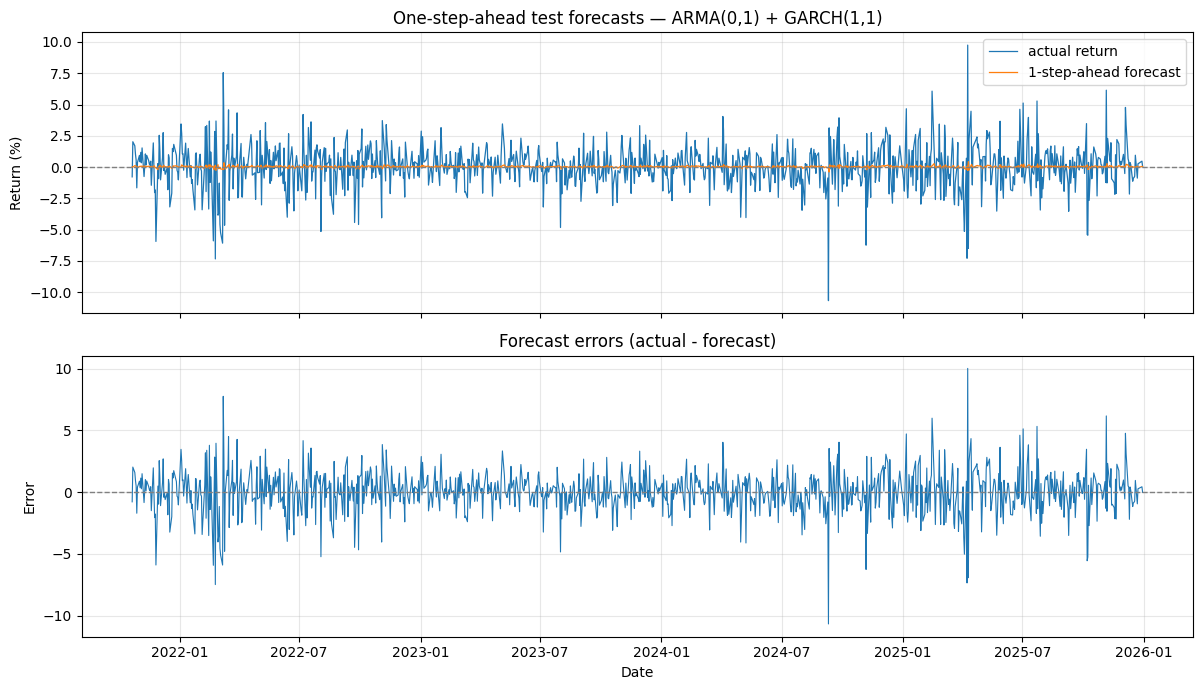

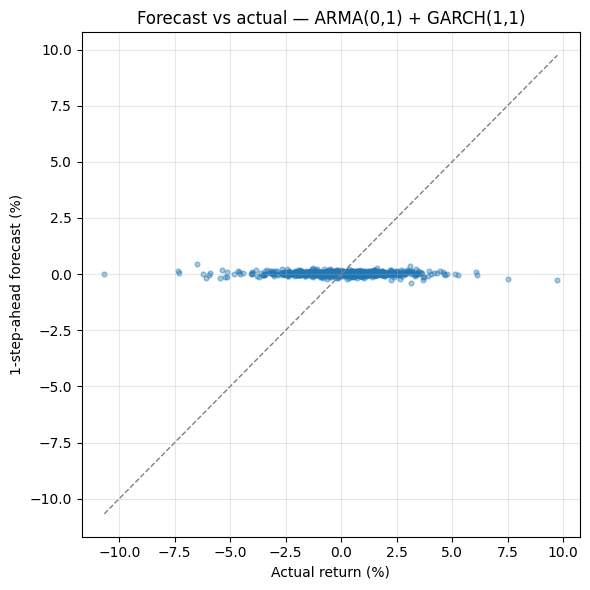

Selected model: ARMA(0,1) + GARCH(1,1)
Test RMSE: 1.7458
Test MAE:  1.2667


In [34]:
# One-step-ahead forecast vs actual for the in-sample-selected model

selected_key = selected_model_keys['best_AIC']
selected_model = fitted_models[selected_key]
test_score = score_model_on_series(selected_model, test_y)

test_dates = returns_df.loc[test_y.index, 'Date']
actual = pd.Series(test_y.values, index=test_dates, name='actual')
forecast = pd.Series(test_score['mean_forecast'], index=test_dates, name='forecast')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(actual.index, actual.values, linewidth=0.9, label='actual return')
axes[0].plot(forecast.index, forecast.values, linewidth=0.9, label='1-step-ahead forecast')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title(f'One-step-ahead test forecasts — {selected_model["order"]}')
axes[0].set_ylabel('Return (%)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)

axes[1].plot(test_dates, test_score['residuals'], linewidth=0.8)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Forecast errors (actual - forecast)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Error')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual.values, forecast.values, alpha=0.4, s=12)
lims = [
    min(actual.min(), forecast.min()),
    max(actual.max(), forecast.max()),
]
ax.plot(lims, lims, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Actual return (%)')
ax.set_ylabel('1-step-ahead forecast (%)')
ax.set_title(f'Forecast vs actual — {selected_model["order"]}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Selected model: {selected_model["order"]}')
print(f'Test RMSE: {test_score["RMSE"]:.4f}')
print(f'Test MAE:  {test_score["MAE"]:.4f}')

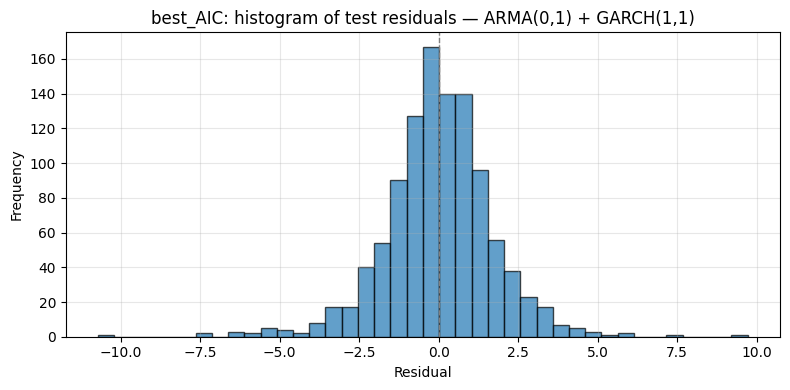

In [27]:
# Histogram of test residuals for selected models

seen_keys = set()
for label, key in selected_model_keys.items():
    if key in seen_keys or key not in fitted_models:
        continue
    seen_keys.add(key)

    model = fitted_models[key]
    residuals = score_model_on_series(model, test_y)['residuals']

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(residuals, bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{label}: histogram of test residuals — {model["order"]}')
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()